# Fleet model plots

Select a completed fleet-model run and create publication-ready figures from its saved results.

In [9]:
# Enter the exact run-directory name here.
RUN_NAME = "fleet_size_no_change_linear__2026-08-28_173504" 

In [10]:
import json
from pathlib import Path

import pandas as pd


def find_final_model_dir() -> Path:
    cwd = Path.cwd().resolve()
    candidates = [cwd, *cwd.parents]
    for candidate in candidates:
        if candidate.name == "Final_Model":
            return candidate
        nested = candidate / "Final_Model"
        if nested.is_dir():
            return nested
    raise FileNotFoundError("Could not locate the Final_Model directory.")


FINAL_MODEL_DIR = find_final_model_dir()
RUN_DIR = FINAL_MODEL_DIR / "outputs" / "fleet_model" / RUN_NAME
if not RUN_DIR.is_dir():
    available_runs = sorted(
        path.name
        for path in (FINAL_MODEL_DIR / "outputs" / "fleet_model").glob("*")
        if path.is_dir()
    )
    raise FileNotFoundError(
        f"Fleet-model run not found: {RUN_DIR}\n"
        f"Available runs: {available_runs}"
    )

manifest_path = RUN_DIR / "run_manifest.json"
if not manifest_path.is_file():
    raise FileNotFoundError(f"Run manifest not found: {manifest_path}")
manifest = json.loads(manifest_path.read_text(encoding="utf-8"))
if manifest.get("status") != "success":
    raise ValueError(
        f"Run {RUN_NAME!r} has status {manifest.get('status')!r}; "
        "plots are only created for successful runs."
    )

config_name = manifest.get("run_name")
if not config_name:
    raise ValueError(f"Manifest has no run_name: {manifest_path}")

stock_path = RUN_DIR / f"{config_name}__policy_final_stock_all.csv"
if not stock_path.is_file():
    raise FileNotFoundError(f"Fleet stock result not found: {stock_path}")

policy_final_stock_all = pd.read_csv(
    stock_path, sep=";", encoding="utf-8-sig"
)

print(f"Selected run: {RUN_NAME}")
print(f"Run status:   {manifest['status']}")
print(f"Input file:   {stock_path.name}")
print(f"Loaded rows:  {len(policy_final_stock_all):,}")

Selected run: fleet_size_no_change_linear__2026-08-28_173504
Run status:   success
Input file:   fleet_size_no_change_linear__policy_final_stock_all.csv
Loaded rows:  355,759


## Vehicle stock by powertrain and scenario

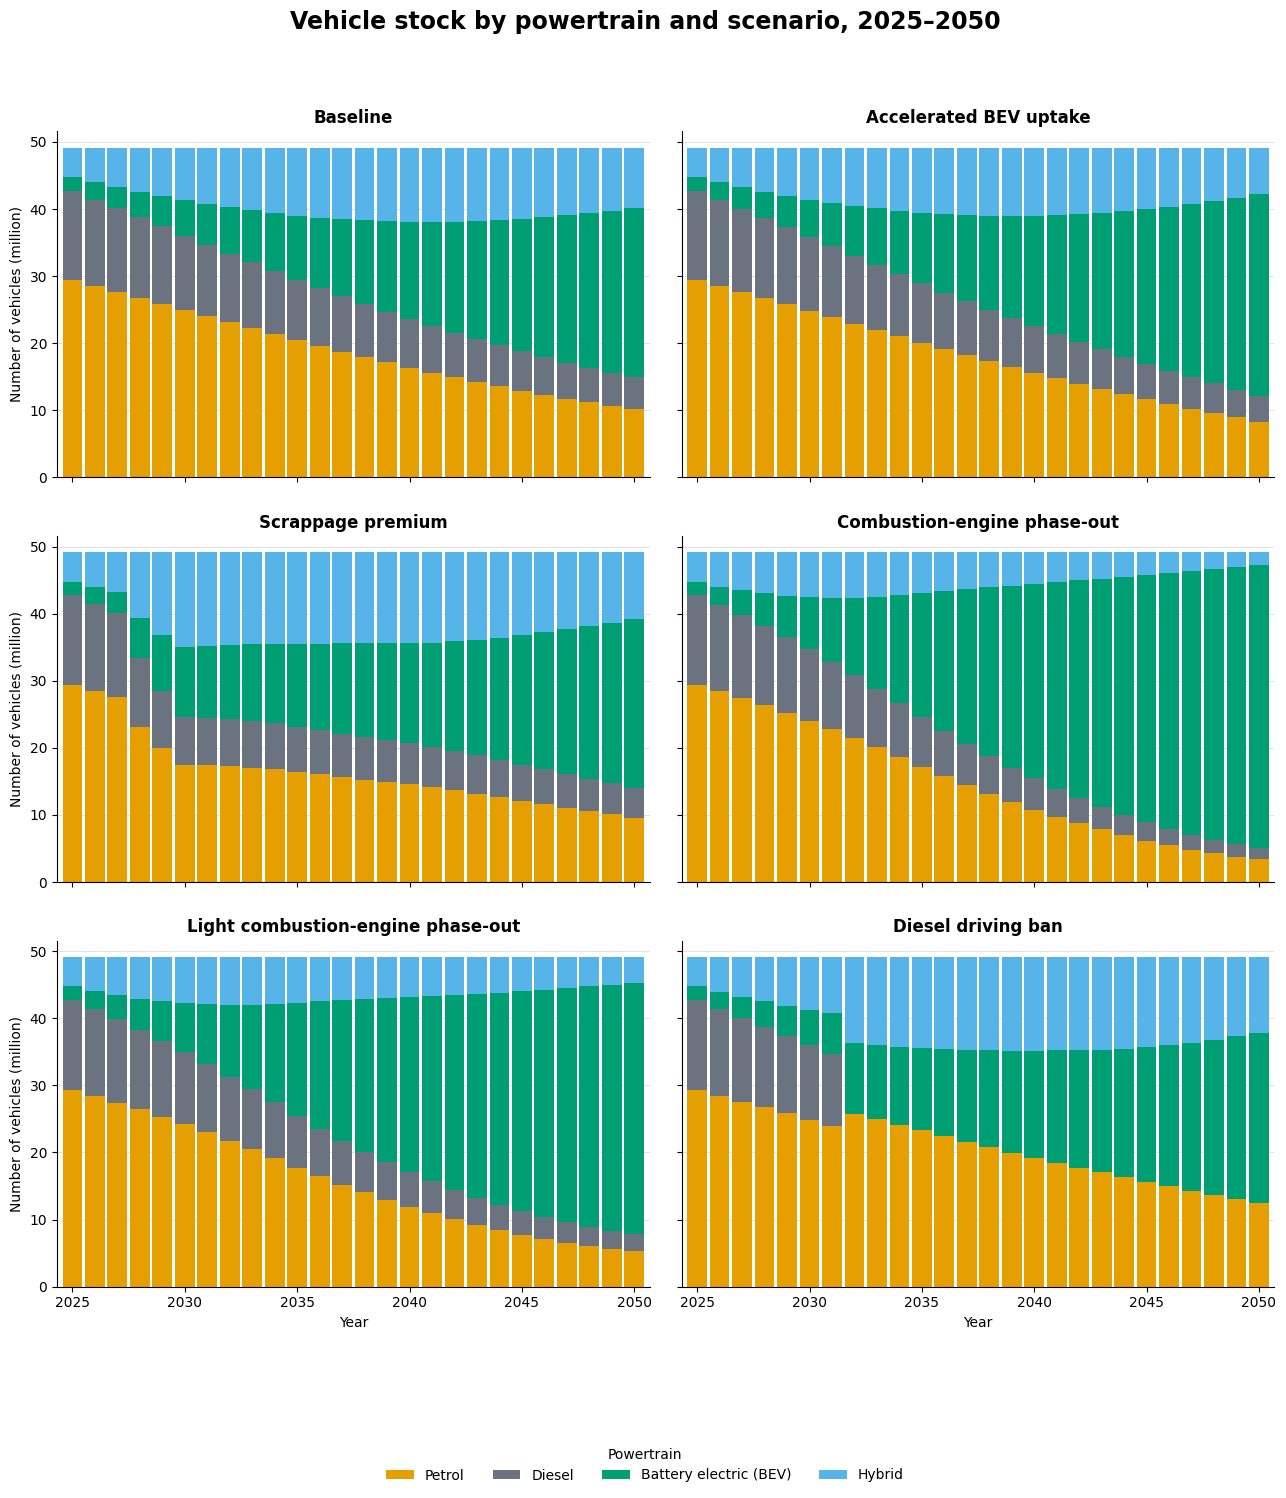

Figure saved to:
C:\Users\annic\OneDrive\Dokumente\Master Technischer Umweltschutz\Master Thesis\Emission_Trajectory_Thesis\Final_Model\outputs\fleet_model\fleet_size_no_change_linear__2026-08-28_173504\vehicle_stock_by_powertrain_and_scenario_2025_2050.png


In [11]:
# Vehicle stock by powertrain and scenario (English, publication layout)
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter, MultipleLocator

plot_df = policy_final_stock_all.copy()
plot_df["Jahr"] = pd.to_numeric(plot_df["Jahr"], errors="coerce")
plot_df["finaler_bestand"] = pd.to_numeric(
    plot_df["finaler_bestand"], errors="coerce"
)
plot_df = plot_df[plot_df["Jahr"].between(2025, 2050)].dropna(
    subset=["Jahr", "finaler_bestand"]
)
plot_df["Jahr"] = plot_df["Jahr"].astype(int)

scenario_order = [
    "baseline_ev_growth",
    "stronger_ev_growth",
    "abwrackpraemie",
    "verbrenneraus_2035",
    "verbrenneraus_light",
    "diesel_fahrverbot",
]
scenario_labels = {
    "baseline_ev_growth": "Baseline",
    "stronger_ev_growth": "Accelerated BEV uptake",
    "abwrackpraemie": "Scrappage premium",
    "verbrenneraus_2035": "Combustion-engine phase-out",
    "verbrenneraus_light": "Light combustion-engine phase-out",
    "diesel_fahrverbot": "Diesel driving ban",
}
powertrain_labels = {
    "Benzin": "Petrol",
    "Diesel": "Diesel",
    "Elektro (BEV)": "Battery electric (BEV)",
    "Hybrid": "Hybrid",
    "Sonstige": "Other",
    "Flüssiggas (LPG) (einschl. bivalent)": "Liquefied petroleum gas (LPG)",
    "Erdgas (CNG) (einschl. bivalent)": "Compressed natural gas (CNG)",
}
powertrain_colors = {
    "Benzin": "#E69F00",
    "Diesel": "#6B7280",
    "Elektro (BEV)": "#009E73",
    "Hybrid": "#56B4E9",
    "Sonstige": "#CC79A7",
    "Flüssiggas (LPG) (einschl. bivalent)": "#D55E00",
    "Erdgas (CNG) (einschl. bivalent)": "#0072B2",
}

agg_plot = (
    plot_df.groupby(["Szenario", "Jahr", "Antriebsart"], as_index=False)[
        "finaler_bestand"
    ].sum()
)
available_scenarios = set(agg_plot["Szenario"].unique())
missing_scenarios = [
    scenario for scenario in scenario_order if scenario not in available_scenarios
]
if missing_scenarios:
    raise ValueError(f"Scenarios missing from fleet results: {missing_scenarios}")

powertrains = list(
    dict.fromkeys(
        [name for name in powertrain_labels if name in agg_plot["Antriebsart"].unique()]
        + sorted(set(agg_plot["Antriebsart"].unique()) - set(powertrain_labels))
    )
)
fallback_colors = plt.get_cmap("tab20").colors
colors = [
    powertrain_colors.get(name, fallback_colors[i % len(fallback_colors)])
    for i, name in enumerate(powertrains)
]

fig, axes = plt.subplots(
    3, 2, figsize=(13, 15), sharex=True, sharey=True, squeeze=False
)
years = range(2025, 2051)

for ax, scenario in zip(axes.flat, scenario_order):
    pivot = (
        agg_plot.loc[agg_plot["Szenario"] == scenario]
        .pivot_table(
            index="Jahr",
            columns="Antriebsart",
            values="finaler_bestand",
            aggfunc="sum",
            fill_value=0,
        )
        .reindex(index=years, columns=powertrains, fill_value=0)
    )
    pivot.plot(
        kind="bar",
        stacked=True,
        ax=ax,
        width=0.88,
        color=colors,
        edgecolor="none",
    )
    ax.set_title(scenario_labels[scenario], fontsize=12, fontweight="semibold")
    ax.set_xlabel("Year")
    ax.set_ylabel("Number of vehicles (million)")
    ax.yaxis.set_major_locator(MultipleLocator(10_000_000))
    ax.yaxis.set_major_formatter(
        FuncFormatter(lambda value, _: f"{value / 1_000_000:.0f}")
    )
    tick_positions = list(range(0, len(pivot.index), 5))
    if len(pivot.index) - 1 not in tick_positions:
        tick_positions.append(len(pivot.index) - 1)
    ax.set_xticks(tick_positions)
    ax.set_xticklabels([pivot.index[i] for i in tick_positions], rotation=0)
    ax.grid(axis="y", color="#D1D5DB", linewidth=0.7, alpha=0.7)
    ax.set_axisbelow(True)
    ax.spines[["top", "right"]].set_visible(False)
    if ax.get_legend() is not None:
        ax.get_legend().remove()

handles, _ = axes.flat[0].get_legend_handles_labels()
legend_labels = [powertrain_labels.get(name, name) for name in powertrains]
fig.legend(
    handles,
    legend_labels,
    title="Powertrain",
    loc="lower center",
    ncol=4,
    frameon=False,
    bbox_to_anchor=(0.5, -0.01),
)
fig.suptitle(
    "Vehicle stock by powertrain and scenario, 2025–2050",
    fontsize=17,
    fontweight="bold",
)
fig.tight_layout(rect=[0, 0.09, 1, 0.95], h_pad=2.0, w_pad=1.5)

output_path = (
    RUN_DIR / "vehicle_stock_by_powertrain_and_scenario_2025_2050.png"
)
fig.savefig(output_path, dpi=300, bbox_inches="tight", facecolor="white")
plt.show()
print(f"Figure saved to:\n{output_path}")